CAM1H
  Crab Source Position in the camera local-frame coords
  - shifts: (-52.55320588166768, -56.199841769251)
  - angles: (np.float64(-14.510818374736035), np.float64(-15.470935671066176))
  - RA - DEC: CoordEquatorial(ra=83.6332015991211, dec=22.014499664306626)
  - CAM pointings: {'z': CoordEquatorial(ra=65.6737015953277, dec=35.6486362123488), 'x': CoordEquatorial(ra=257.33165649948, dec=53.7838910823791)}
  - Wanted CAM pointings: CoordEquatorial(ra=83.1078519664901, dec=21.540083357047777)



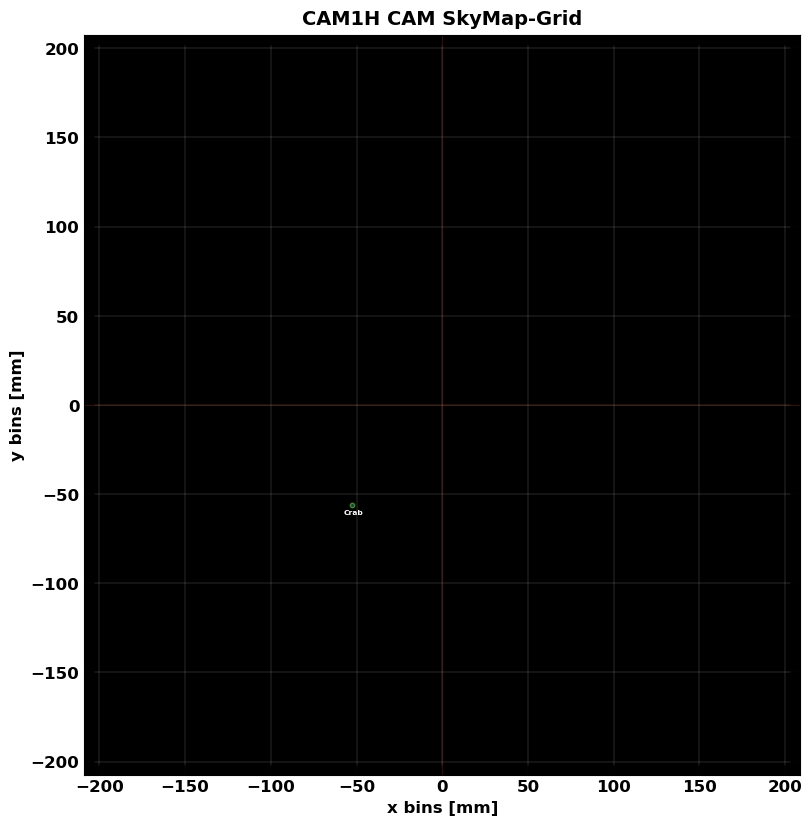

In [ ]:
from pathlib import Path

from bloodmoon.coords import equatorial2shift, shift2angle, shift2equatorial, angle2shift
from bloodmoon.mask import codedmask, count, decode

import darksun as ds
from darksun.types import LogEntry
from darksun.show import skyfield_map


# setup mask and data
base_path = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
skyfield = 'Crab/PointingTests'
mask_FITS = 'wfm_mask_NTHT_20250725.fits'
data_FITS = 'test_camera_tilt'
filepath = f'{base_path}/{skyfield}/{data_FITS}'

UPX, UPY = 1, 1
wfm = codedmask(f'{base_path}/{mask_FITS}', UPX, UPY)

CrabRA = 83.6332015991211
CrabDEC = 22.0144996643066
cameras = tuple(p.name for p in Path(filepath).glob('*cam1h*') if p.is_dir())


for camID in cameras:
    sdlA = ds.get_data(f'{filepath}/{camID}/{data_FITS}_{camID}_detected.fits')
    detector, _ = count(wfm, sdlA.DLdata)
    sky = decode(wfm, detector)
    shiftx, shifty = equatorial2shift(sdlA, wfm, CrabRA, CrabDEC)
    thetax, thetay = tuple(map(lambda x: shift2angle(wfm, x), (shiftx, shifty)))
    print(
        f'{camID.upper()}\n'
        f'  Crab Source Position in the camera local-frame coords\n'
        f'  - shifts: {shiftx, shifty}\n'
        f'  - angles: {thetax, thetay}\n'
        f'  - RA - DEC: {shift2equatorial(sdlA, wfm, shiftx, shifty)}\n'
        f'  - CAM pointings: {sdlA.pointings}\n'
        f'  - Wanted CAM pointings: {shift2equatorial(
            sdlA, wfm, angle2shift(wfm, -15.0), angle2shift(wfm, -15.0),
        )}\n'
    )

    # show source position in skymap
    params = (
        LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
    )
    source_log = ds.create_log(
        params=params,
        name=f'{camID} CAM'
    )
    source_log.update(tuple((p.entry, val) for p, val in zip(params, ('Crab', shiftx, shifty))))
    skyfield_map(
        log=source_log,
        camera=wfm,
    )

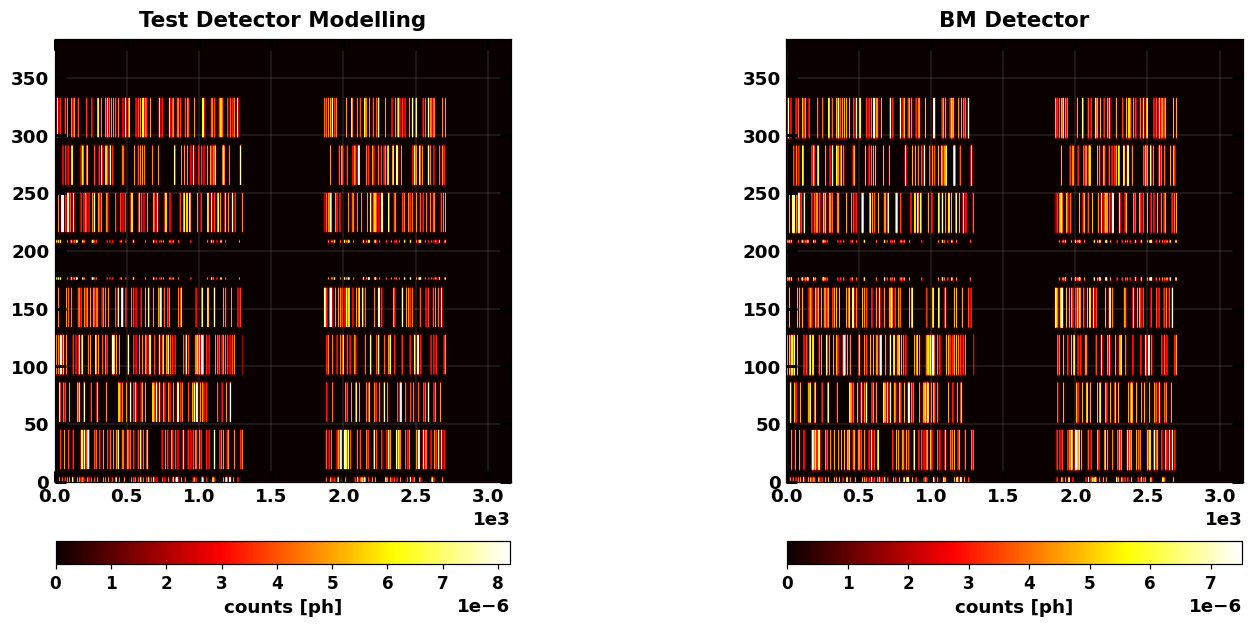

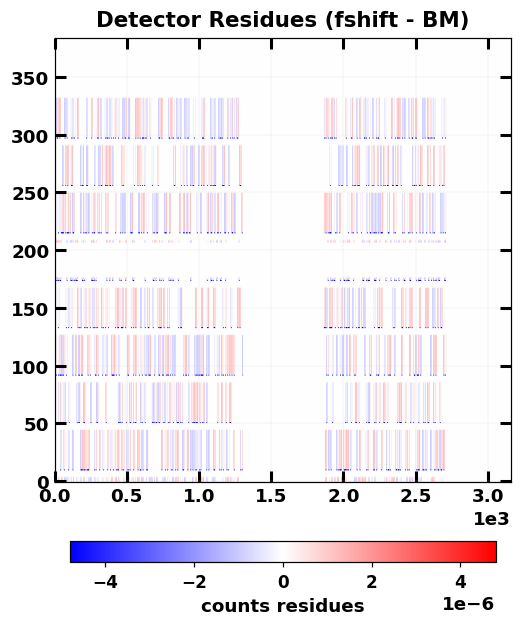

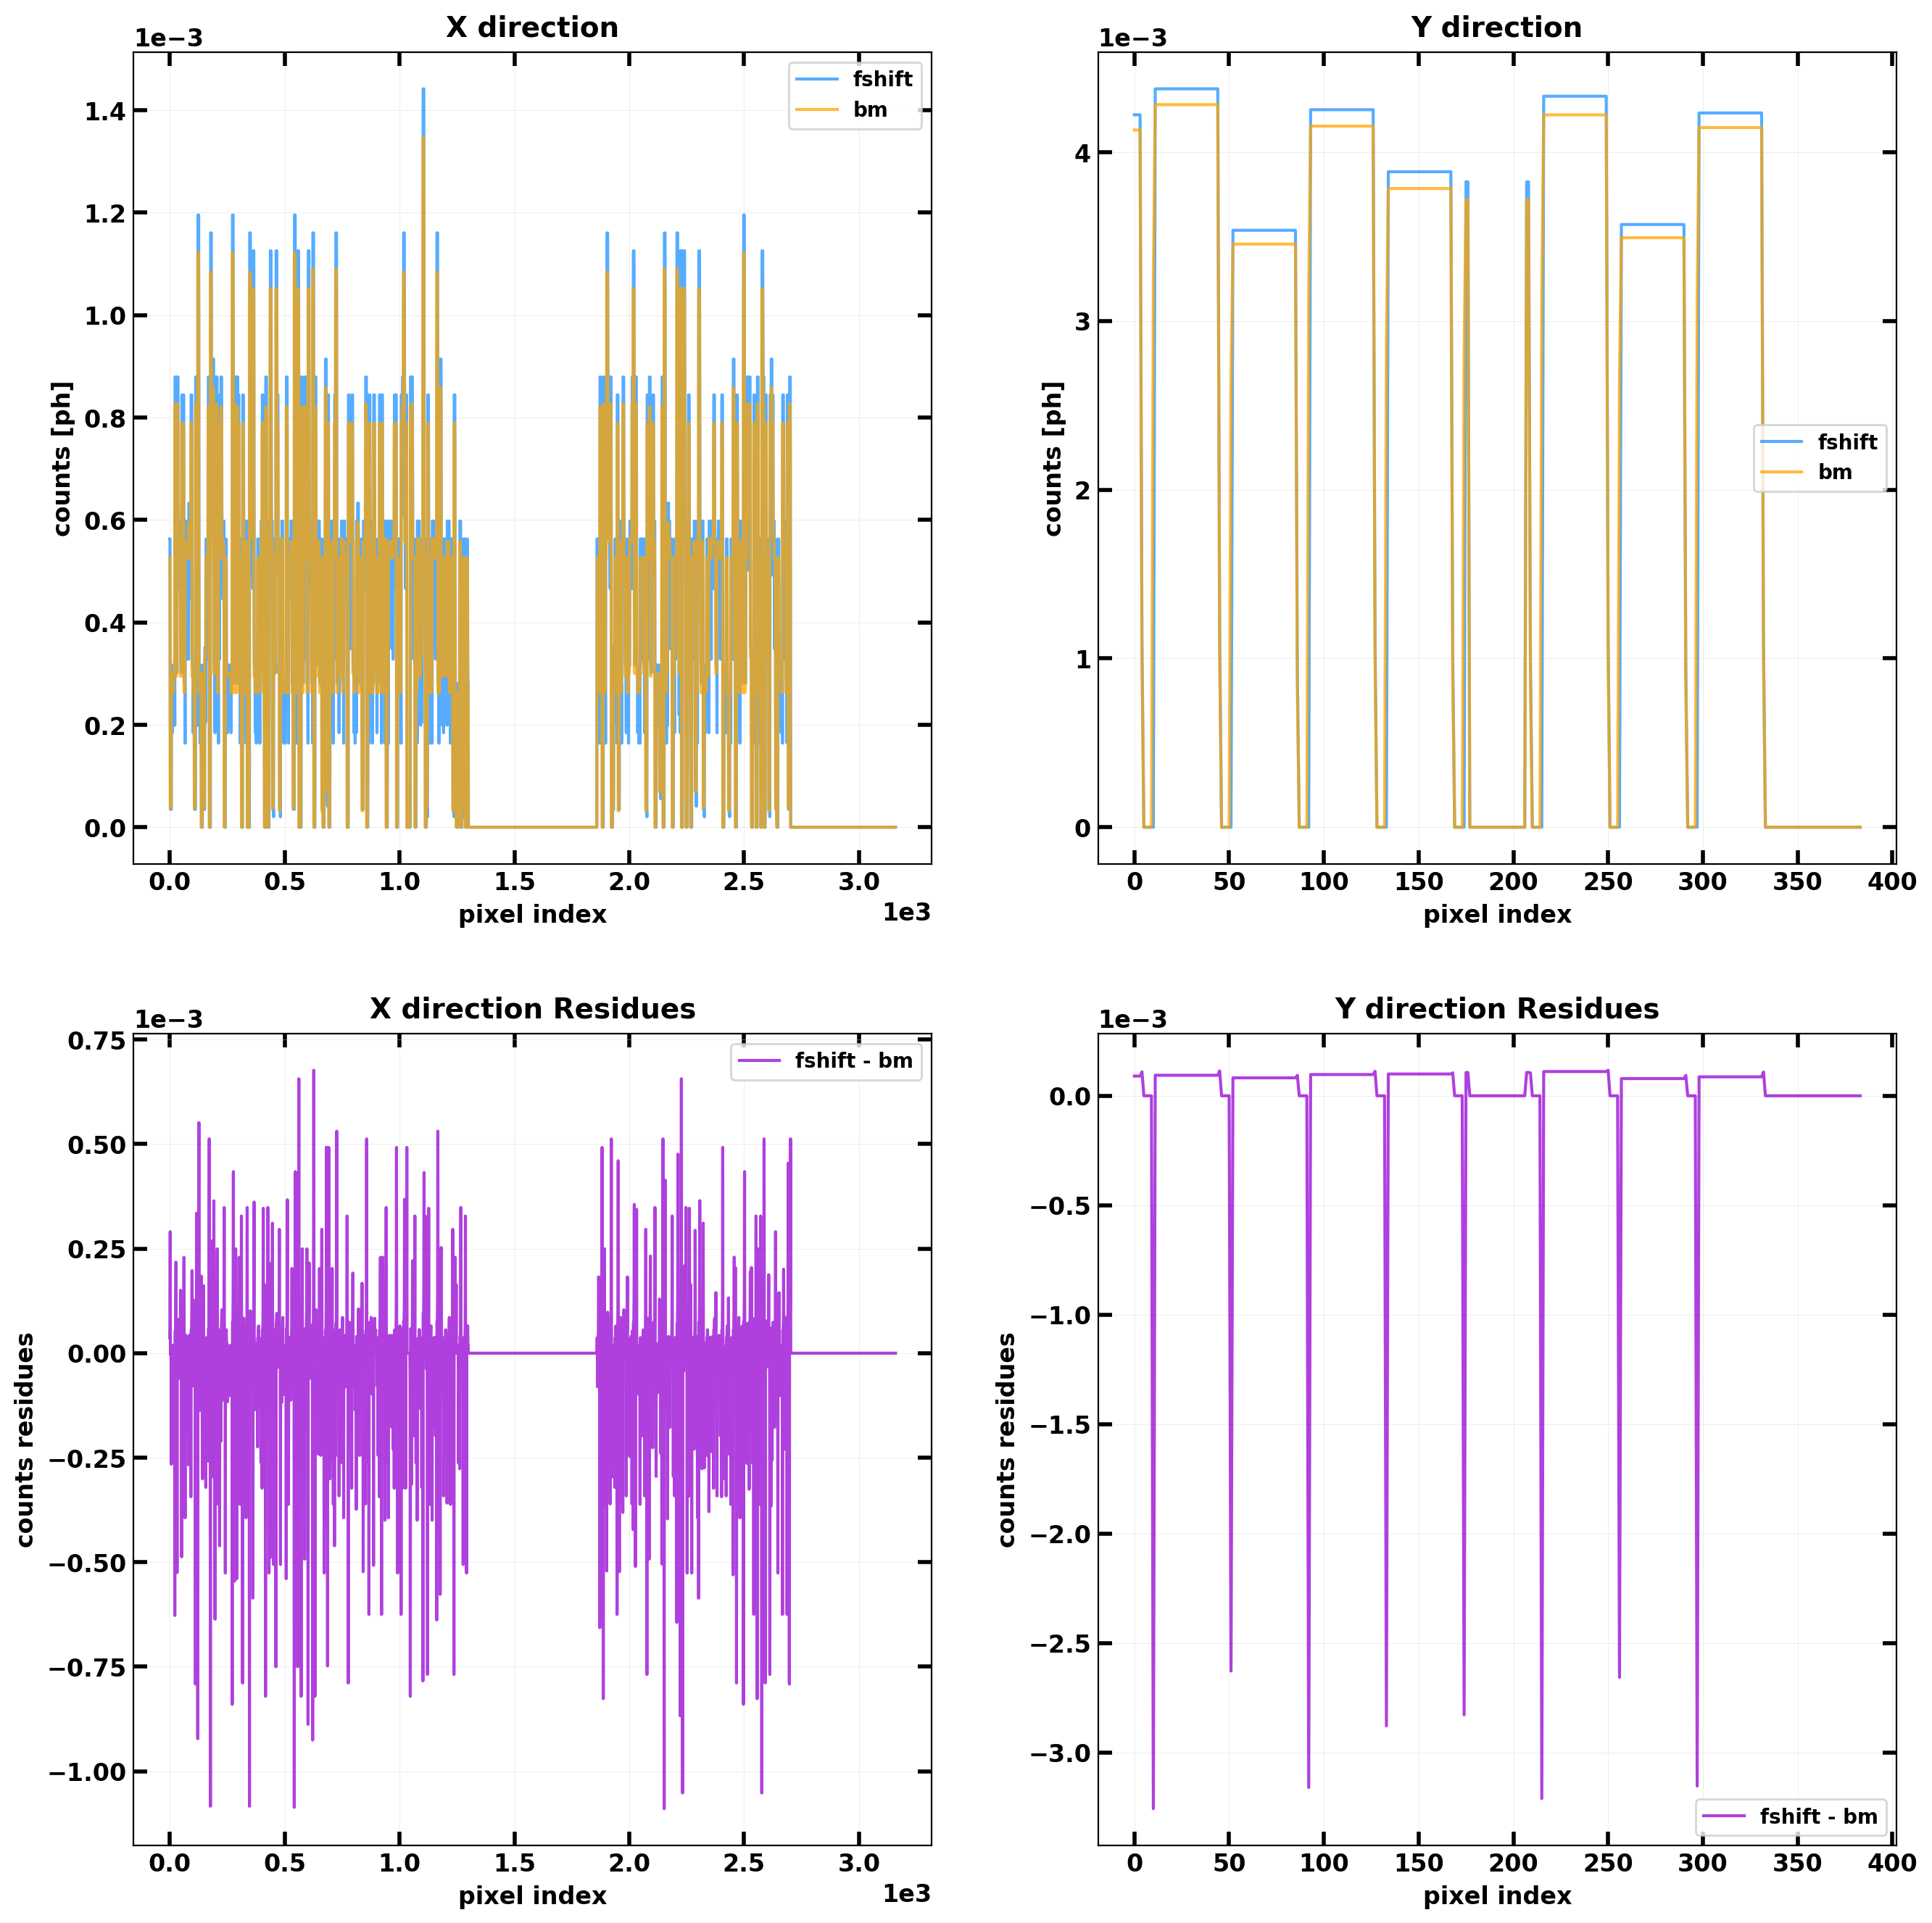

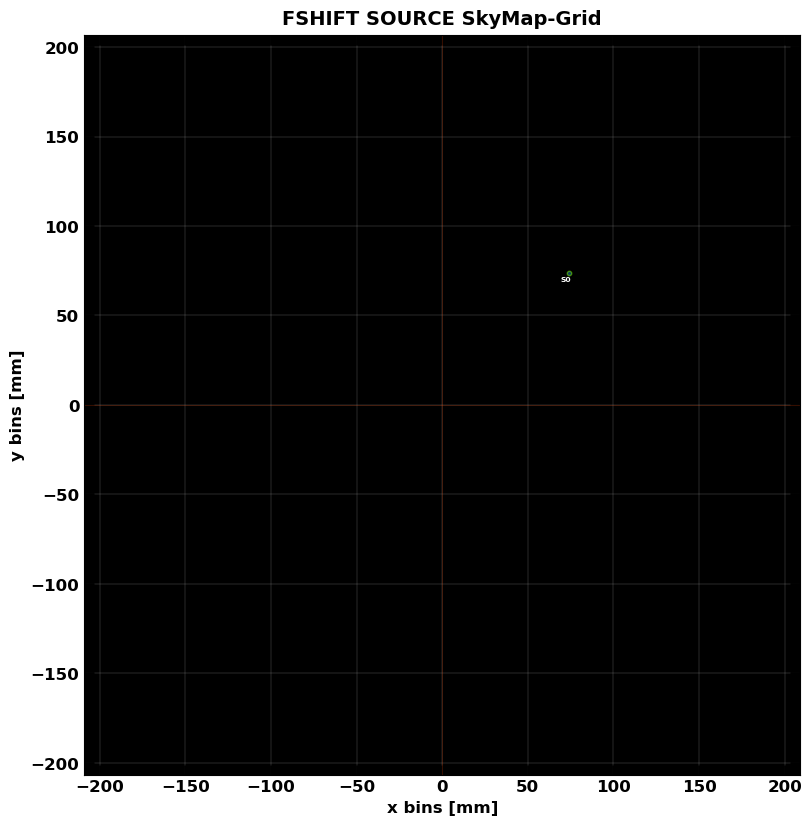

In [ ]:
assert False

import numpy as np

from bloodmoon.mask import codedmask
from bloodmoon.coords import angle2shift
from bloodmoon.optim import model_shadowgram as bm_shadowgram

from darksun.types import LogEntry
from darksun.data import create_log
from darksun.show import map4image, image_plot
from darksun.show import map4plot, plot
from darksun.show import skyfield_map

from maskpattern_shift import model_shadowgram


# setup mask and instr effects
#basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
basepath = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 5, 1
wfm = codedmask(maskpath, UPX, UPY)
VIGNETTING = False
PSFY = False

ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)

# source local-frame coords and detector images
shifty, shiftx = (
    angle2shift(wfm, 20),
    angle2shift(wfm, 20),
)

det = model_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY)
dmap1 = map4image(
    det,
    title='Test Detector Modelling',
    cbarlabel='counts [ph]',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'hot',
        'aspect': ASPECT,
    },
)

bm_det = bm_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY)
dmap2 = map4image(
    bm_det,
    title='BM Detector',
    cbarlabel='counts [ph]',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'hot',
        'aspect': ASPECT,
    },
)
image_plot((dmap1, dmap2), ncols=2)

# detectors residuals
res = det - bm_det
LIM = res.max()
dmap_res = map4image(
    res,
    title='Detector Residues (fshift - BM)',
    cbarlabel='counts residues',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'bwr',
        'aspect': ASPECT,
        'vmin': -LIM,
        'vmax': LIM,
    },
)
image_plot(dmap_res)


# collapse along axes
collapsed_x, collapsed_bmx = map(
    lambda x: np.sum(x, axis=0),
    (det, bm_det),
)
collapsed_y, collapsed_bmy = map(
    lambda x: np.sum(x, axis=1),
    (det, bm_det),
)
dmapx = map4plot(
    arrs=(collapsed_x, collapsed_bmx),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_x.max(), collapsed_bmx.max())),
)
dmapy = map4plot(
    arrs=(collapsed_y, collapsed_bmy),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_y.max(), collapsed_bmy.max())),
)
dmapx_res = map4plot(
    arrs=collapsed_x - collapsed_bmx,
    title='X direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('fshift - bm'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
dmapy_res = map4plot(
    arrs=collapsed_y - collapsed_bmy,
    title='Y direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('fshift - bm'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
plot(
    dmaps=(dmapx, dmapy, dmapx_res, dmapy_res),
    ncols=2,
    nrows=2,
)


# show source position in skymap
params = (
    LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
)
source_log = create_log(
    params=params,
    name='fshift source'
)
source_log.update(tuple((p.entry, val) for p, val in zip(params, ('S0', shiftx, shifty))))
skyfield_map(
    log=source_log,
    camera=wfm,
)

In [ ]:
assert False

# testing and benchmarking fshift wrt scipy shift

import numpy as np
from scipy.ndimage import shift as ndshift

from fract_shift import fshift


def scipy_fshift(arr, shifty, shiftx):
    arr_ = ndshift(
        arr, (shifty, shiftx), output='float', order=1, mode='grid-constant', cval=0.0, prefilter=True,
    )
    return arr_

TOL = 1e-5

a = np.ones((10, 10))
b = (
    (fshift(a, 0, -1), scipy_fshift(a, 0, -1)),
    (fshift(a, 1.6, 0), scipy_fshift(a, 1.6, 0)),
    (fshift(a, -1.6, 0), scipy_fshift(a, -1.6, 0)),
    (fshift(a, 0, 1.6), scipy_fshift(a, 0, 1.6)),
    (fshift(a, 0, -1.6), scipy_fshift(a, 0, -1.6)),
    (fshift(a, 1.3, -1.2), scipy_fshift(a, 1.3, -1.2)),

    (fshift(a, 0, -1), scipy_fshift(a, 0, -1)),
    (fshift(a, 3.1, 0), scipy_fshift(a, 3.1, 0)),
    (fshift(a, -7.8, 0), scipy_fshift(a, -7.8, 0)),
    (fshift(a, 0, 5.2), scipy_fshift(a, 0, 5.2)),
    (fshift(a, 0, -2.8), scipy_fshift(a, 0, -2.8)),
    (fshift(a, 9.3, -4.2), scipy_fshift(a, 9.3, -4.2)),
)

for idx, (fs, scipyfs) in enumerate(b):
    assert np.all(np.abs(fs - scipyfs) < TOL), f"Failed at idx {idx}.\nFS:\n{fs}\n\nSCIPYFS:\n{scipyfs}"



from timeit import timeit
REP = 20

a = np.ones((650, 1040))
sy, sx = 100, 100

t1 = timeit('fshift(a, sy, sx)', globals=globals(), number=REP)        # faster on single cell !!
t2 = timeit('scipy_fshift(a, sy, sx)', globals=globals(), number=REP)  # slower on single cell !!

t1 / REP, t2 / REP

AssertionError: 

In [ ]:
assert False

# benchmarking shadowgram modeling

from timeit import timeit
import numpy as np

from bloodmoon.mask import codedmask

from fract_shift import model_shadowgram
from bloodmoon.optim import model_shadowgram as bm_shadowgram

REP = 200


basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
binsx, binsy = wfm.bins_sky
lowx, highx = binsx[0], binsx[-1]
lowy, highy = binsy[0], binsy[-1]

shifty, shiftx = (
    np.random.uniform(binsy[0], binsy[-1]),
    np.random.uniform(binsx[0], binsx[-1]),
)

t1 = timeit('model_shadowgram(wfm, shiftx, shifty, False, False)', globals=globals(), number=REP)  # faster on single cell !!
t2 = timeit('bm_shadowgram(wfm, shiftx, shifty, False, False)', globals=globals(), number=REP)     # slower on single cell !!

t1 / REP, t2 / REP

(0.0061068047350090636, 0.010409019489998173)

In [1]:
import numpy as np
from numpy.typing import NDArray

from fract_shift2 import model_shadowgram

from bloodmoon.coords import shift2pos, angle2shift
from bloodmoon.mask import codedmask, decode
from bloodmoon.optim import model_shadowgram as bm_shadowgram

import darksun as ds

UPX, UPY = 5, 1
mask_path = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask_NTHT_20250725.fits'
wfm = codedmask(mask_path, UPX, UPY)
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)


thetax, thetay = 20.0, 20.0
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)

VIGNETTING = True
PSFY = False

detector = model_shadowgram(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
bm_detector = bm_shadowgram(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

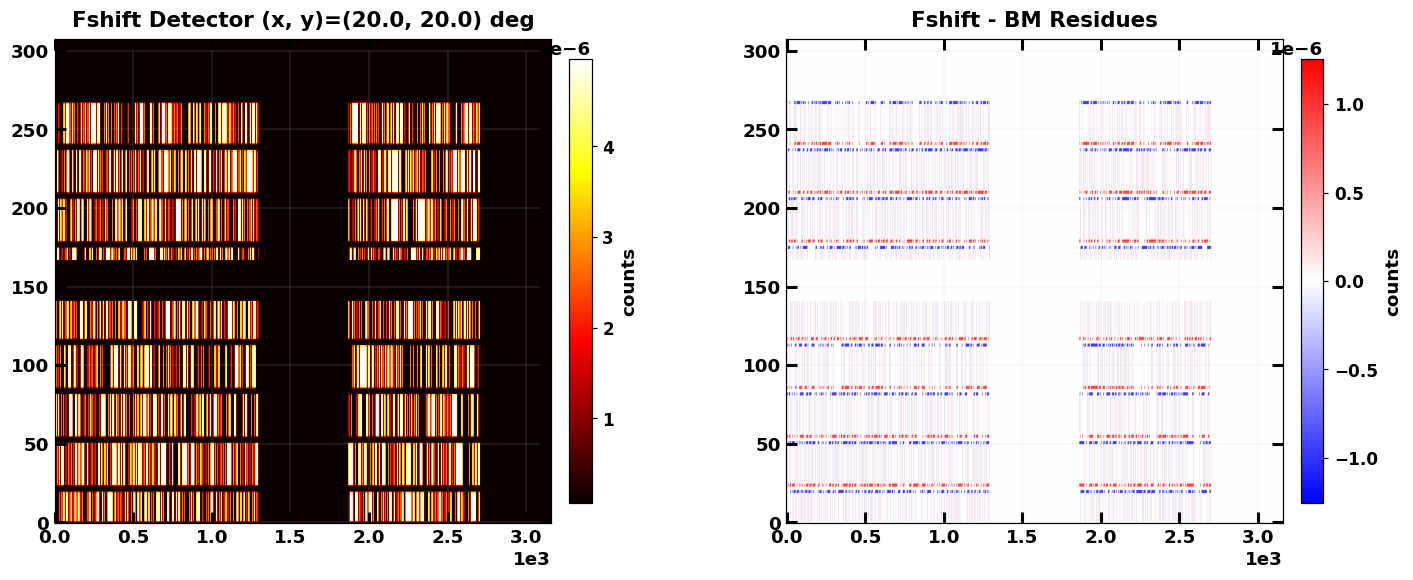

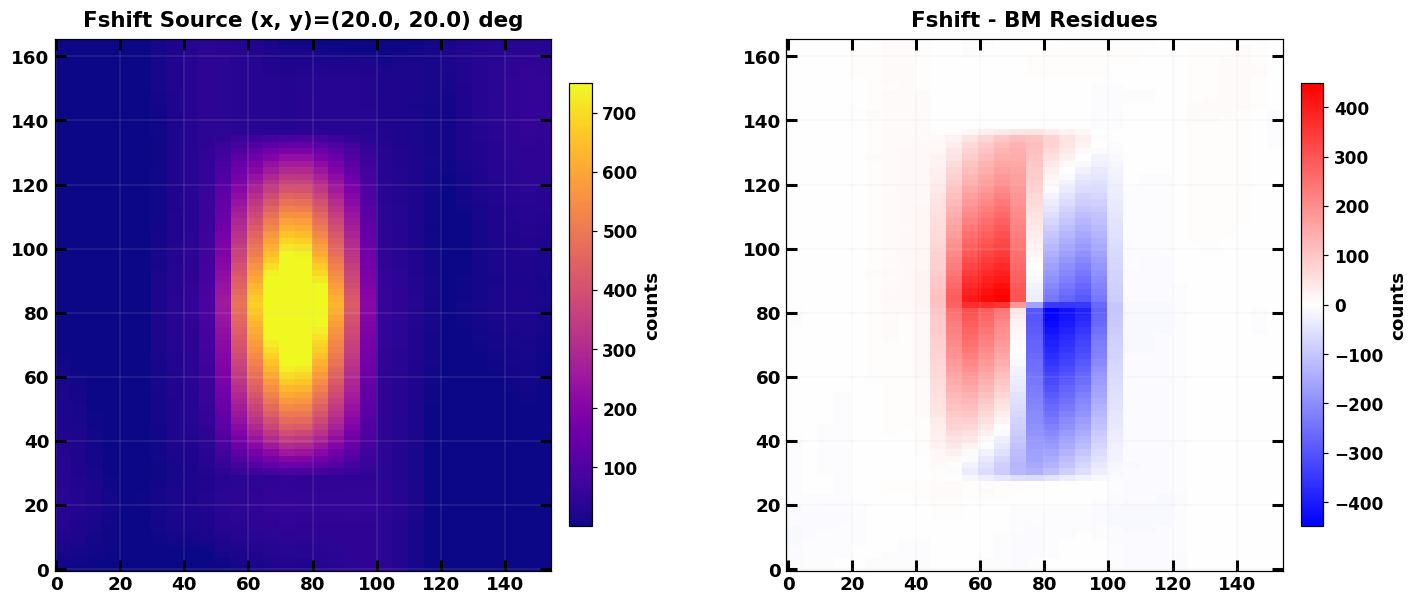

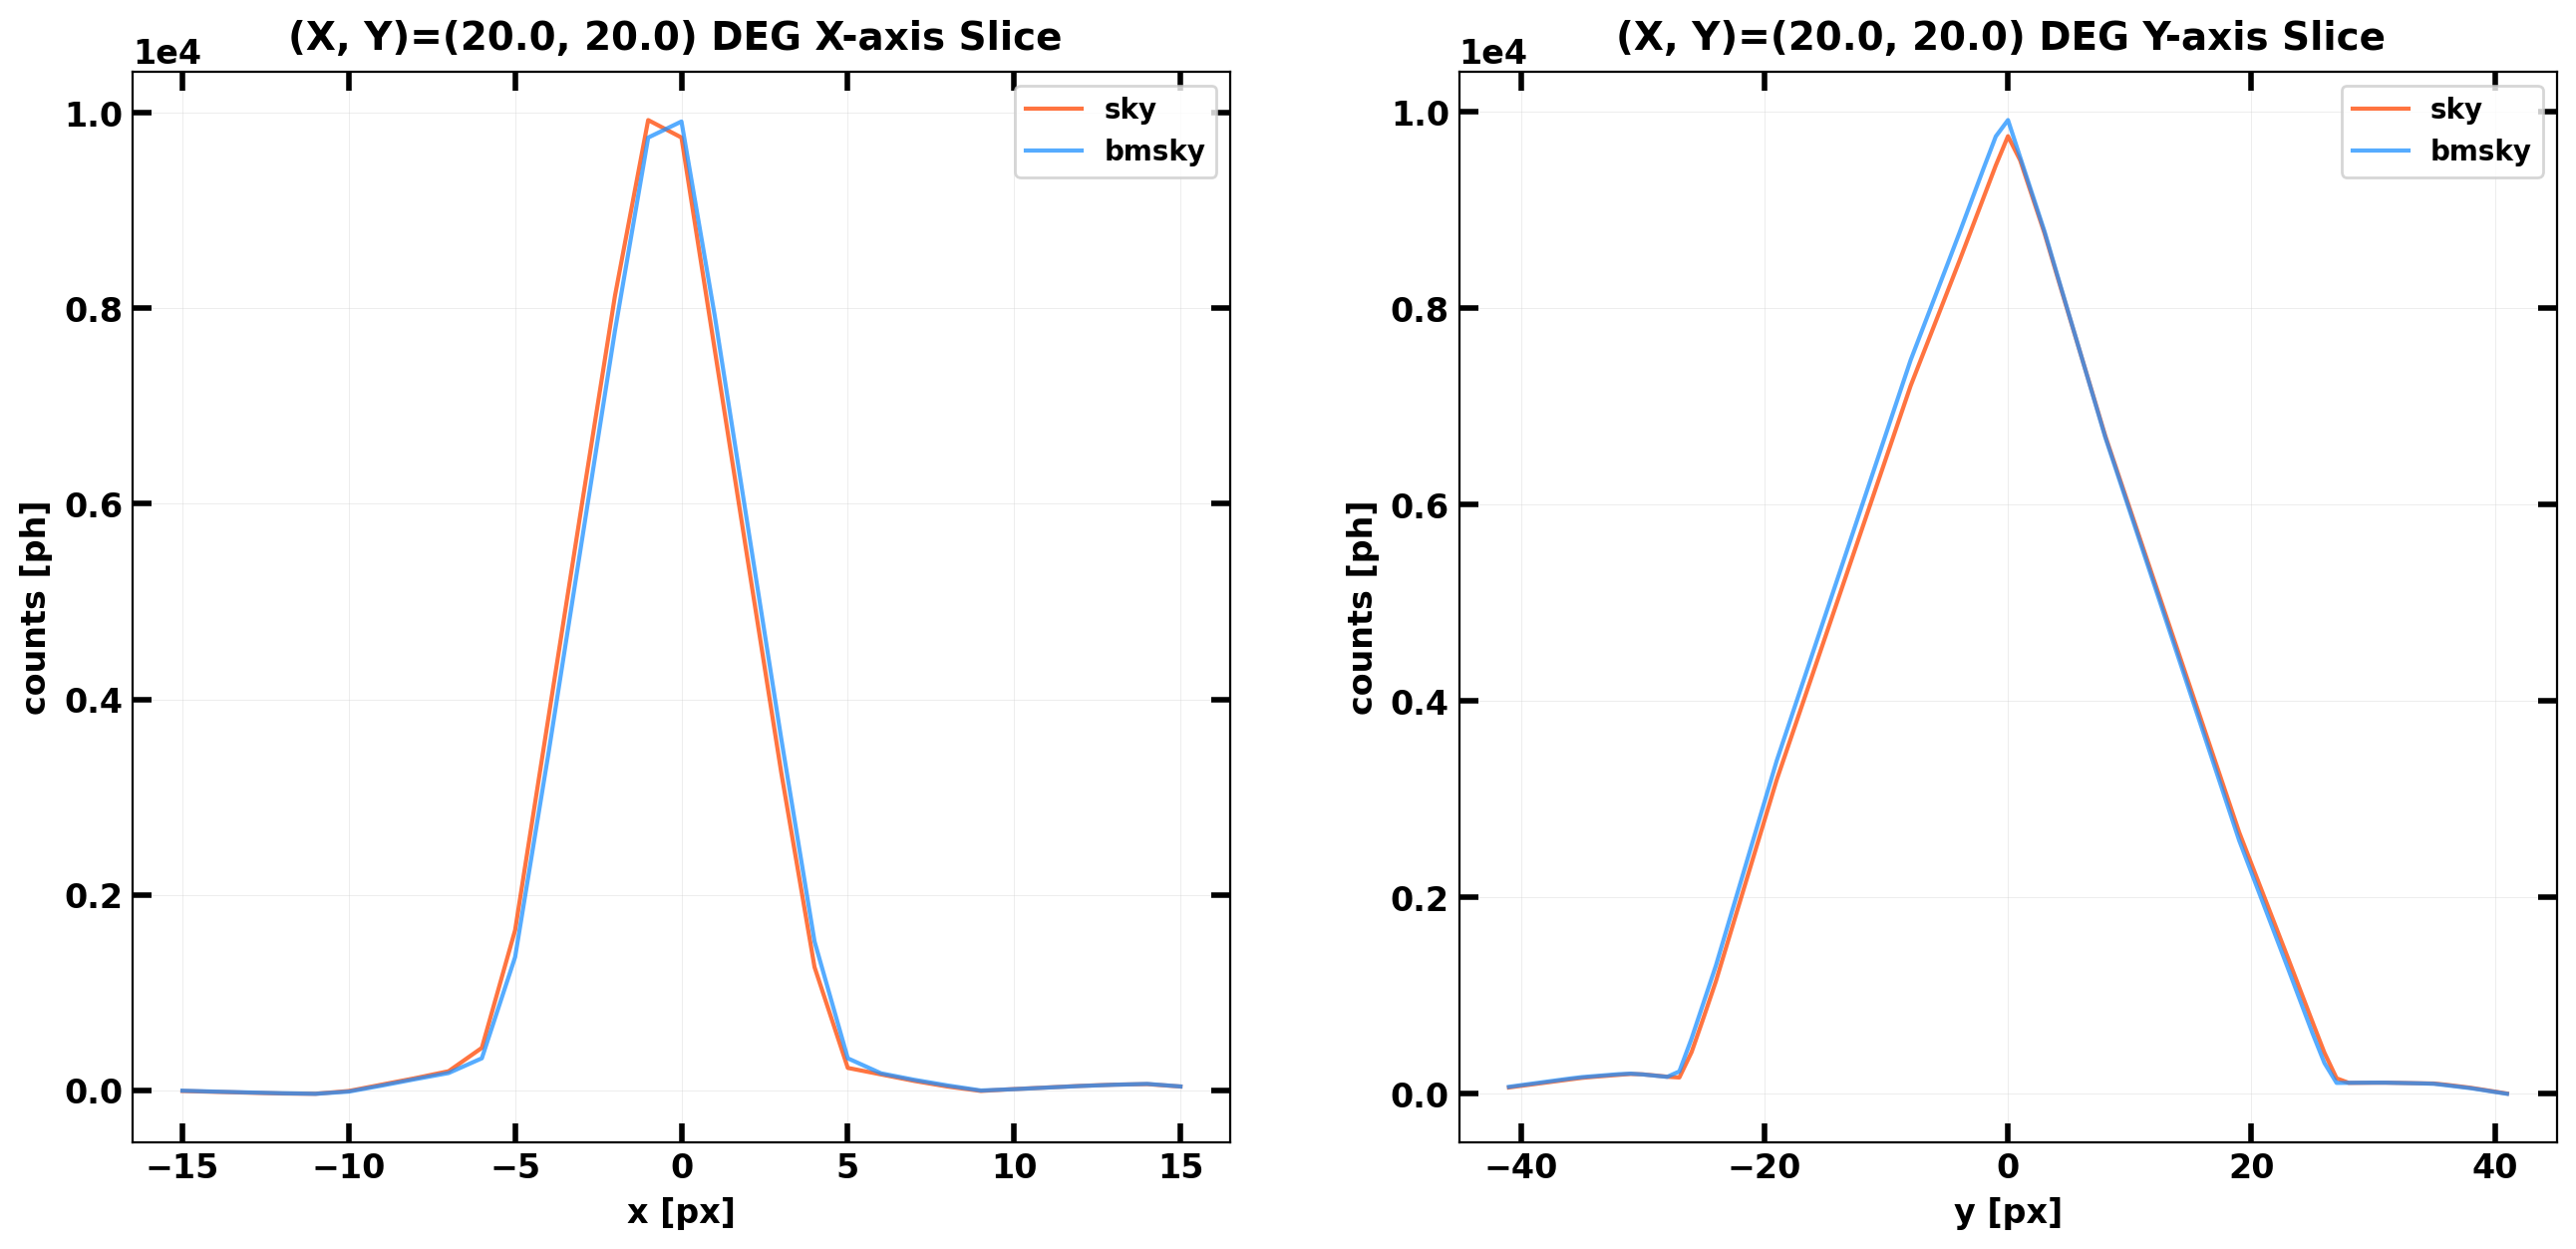

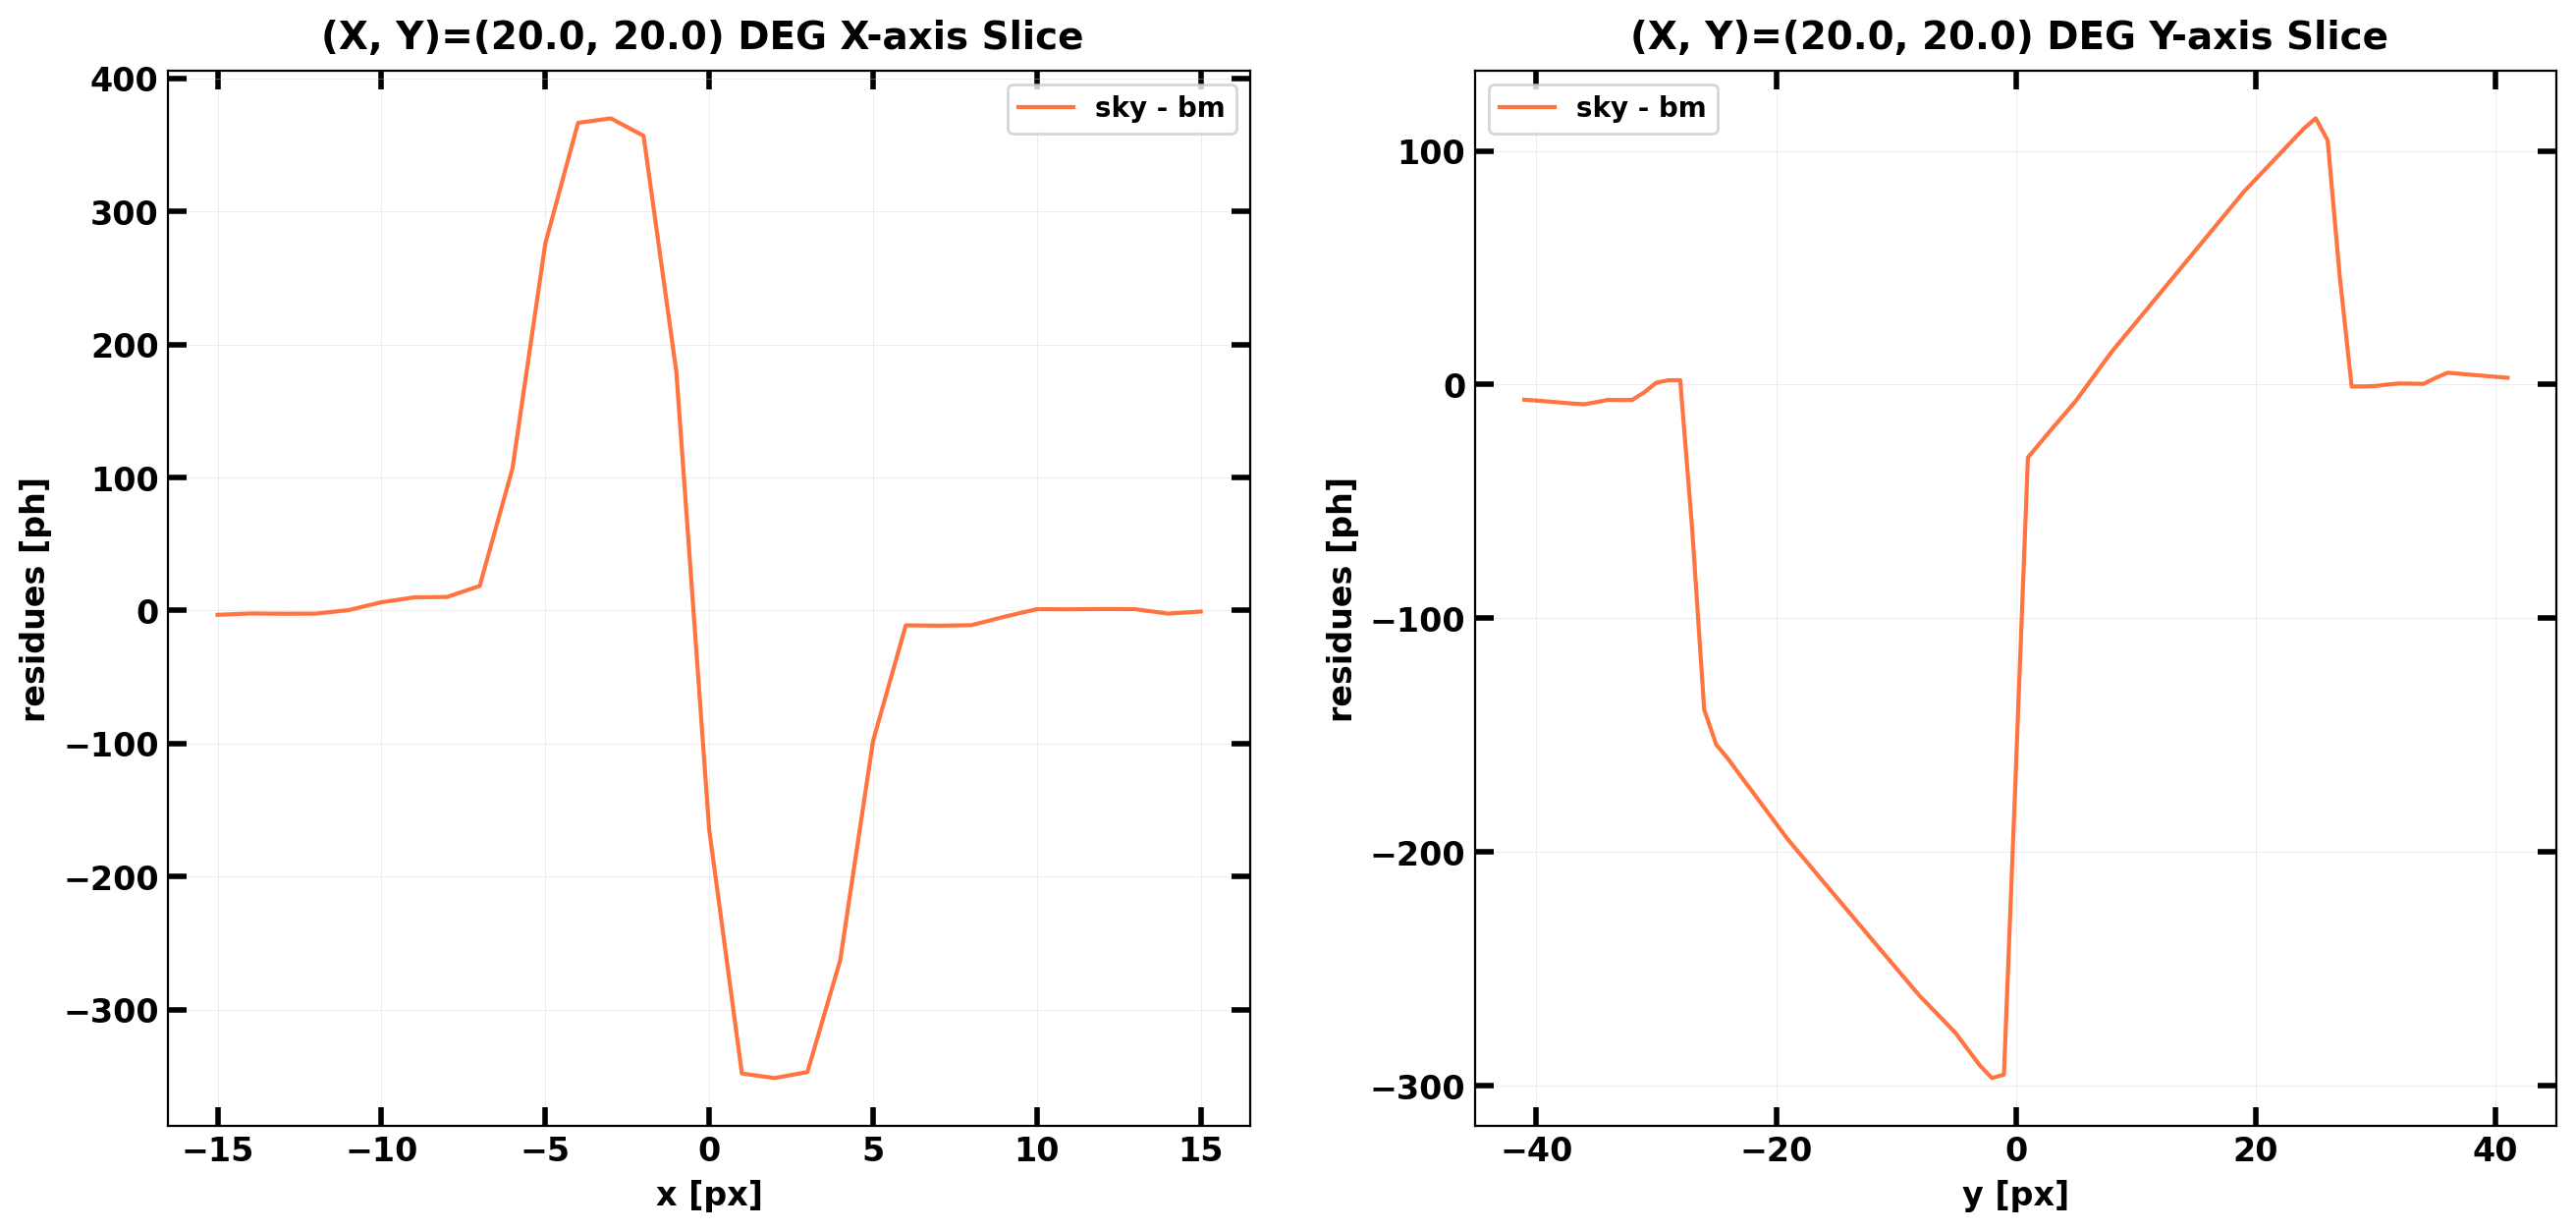

In [3]:
from pathlib import Path

def is_img(save_to: str, name: str, frmt: str = 'png') -> str | None:
    """
    Checks if a Figure has been already saved.
    """
    def savefig(figname: str) -> str:
        """Defines dirpath location to save a Figure."""
        return f'{save_to}/{figname}.{frmt}'

    filepath: str = savefig(name)
    if Path(filepath).is_file():
        return None
    return filepath

def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)


save_to = '/home/edoardo/Desktop/FSHIFT_test_imgs'
tx_, ty_ = map(int, (thetax, thetay))


resdet = detector - bm_detector
lim = np.max(np.abs(resdet))
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title=f'Fshift Detector (x, y)=({thetax}, {thetay}) deg',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=resdet,
            title='Fshift - BM Residues',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'bwr',
                'vmin': -lim,
                'vmax': lim,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
    save_to=is_img(save_to, f'detector_{tx_}{ty_}_sameVignettingSign'),
)


fluence = 1e4
exp = 0.75
sky, bm_sky = map(
    lambda x: fluence * decode(wfm, x),
    (detector, bm_detector),
)
res_sky = sky - bm_sky
lim = np.max(np.abs(res_sky))

i, j = shift2pos(wfm, shiftx, shifty)
crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 10),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 10),
)
crp_sky = ds.crop(
    image=sqrt_display(sky, exp),
    pos=(i, j),
    crp=crp,
)
crp_res_sky = ds.crop(
    image=res_sky,
    pos=(i, j),
    crp=crp,
)
F_UPY, F_UPX = 2, 5

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=ds.upscale(crp_sky, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
            title=f'Fshift Source (x, y)=({thetax}, {thetay}) deg',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 0.75 * pow(fluence, exp),
                #'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=ds.upscale(crp_res_sky, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
            title=f'Fshift - BM Residues',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'bwr',
                'vmin': -lim,
                'vmax': lim,
                #'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
    save_to=is_img(save_to, f'sky_{tx_}{ty_}_sameVignettingSign'),
)
ds.slices_plot(
    sky=(sky, bm_sky),
    pos=(i, j),
    crp=crp,
    source=f'(x, y)=({thetax}, {thetay}) deg',
    labels=('sky', 'bmsky'),
    save_to=is_img(save_to, f'skyslice_{tx_}{ty_}_sameVignettingSign'),
)
ds.slices_plot(
    sky=res_sky,
    pos=(i, j),
    crp=crp,
    source=f'(x, y)=({thetax}, {thetay}) deg',
    ylabel='residues [ph]',
    labels='sky - bm',
    save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
)